In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path



drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive/IA/dados brutos')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# importando dados
def ler_csv(caminho: Path) -> pd.DataFrame:
    return pd.read_csv(caminho, encoding="utf-8-sig", sep=";")

def padronizar_colunas(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
    )
    return df

# Carga das 5 bases (Ajustado typo no arquivo 03)
df_propostas_01 = padronizar_colunas(
    ler_csv(DATA_DIR / "financiamentos_chassi_2026_01.csv")
)
df_propostas_02 = padronizar_colunas(
    ler_csv(DATA_DIR / "financiamentos_chassi_2026_02.csv")
)
df_propostas_03 = padronizar_colunas(
    ler_csv(DATA_DIR / "financiamentos_chassi_2026_03.csv")
)
df_eventos = padronizar_colunas(ler_csv(DATA_DIR / "eventos_target_chassi_90d.csv"))
df_chassis = padronizar_colunas(ler_csv(DATA_DIR / "cadastro_chassi_mock.csv"))

# unindo df_propostas 1, 2 e 3
df_propostas = pd.concat([df_propostas_01, df_propostas_02, df_propostas_03])

In [ ]:
# análise preliminar de df_propostas: visão geral
df_propostas.head(10)

,id_proposta,data_hora_proposta,chassi_id_sintetico,if_id_sintetico,cpf_cnpj_proponente_sintetico,tipo_proponente,valor_financiado,valor_entrada,prazo_meses,canal,uf_proposta
0,PROP_CHASSI_0000000001,2026-01-10 05:36:55,CHASSI_SYN_000035285,IF_SYN_09,DOC_PROP_SYN_000376285,PF,125170.86,48209.12,36,DIGITAL,RJ
1,PROP_CHASSI_0000000002,2026-01-18 14:21:04,CHASSI_SYN_000375721,IF_SYN_18,DOC_PROP_SYN_000235987,PF,34455.69,14855.02,24,DIGITAL,MG
2,PROP_CHASSI_0000000003,2026-01-29 22:43:19,CHASSI_SYN_000416248,IF_SYN_15,DOC_PROP_SYN_000297726,PF,72615.57,16251.28,60,CONCESSIONARIA,SP
3,PROP_CHASSI_0000000004,2026-01-01 12:06:18,CHASSI_SYN_000261667,IF_SYN_09,DOC_PROP_SYN_000593250,PF,116392.04,51887.97,60,LOJA_MULTIMARCA,PR
4,PROP_CHASSI_0000000005,2026-01-22 07:46:16,CHASSI_SYN_000089408,IF_SYN_11,DOC_PROP_SYN_000656252,PF,114506.18,55065.28,24,DIGITAL,SP
5,PROP_CHASSI_0000000006,2026-01-16 17:54:54,CHASSI_SYN_000342217,IF_SYN_07,DOC_PROP_SYN_000705407,PJ,108936.78,26972.11,24,CONCESSIONARIA,PR
6,PROP_CHASSI_0000000007,2026-01-02 18:44:50,CHASSI_SYN_000279354,IF_SYN_17,DOC_PROP_SYN_000349709,PF,190204.25,16245.58,36,CONCESSIONARIA,MG
7,PROP_CHASSI_0000000008,2026-01-25 04:03:38,CHASSI_SYN_000024253,IF_SYN_16,DOC_PROP_SYN_000835490,PJ,62758.39,12957.49,60,CONCESSIONARIA,PR
8,PROP_CHASSI_0000000009,2026-01-08 01:06:57,CHASSI_SYN_000306973,IF_SYN_05,DOC_PROP_SYN_000437775,PF,102466.11,38535.45,48,LOJA_MULTIMARCA,MG
9,PROP_CHASSI_0000000010,2026-01-23 07:02:47,CHASSI_SYN_000280763,IF_SYN_07,DOC_PROP_SYN_000170762,PF,144212.68,76773.10,60,DIGITAL,RJ


In [ ]:
# análise preliminar de df_propostas: colunas, tipos e avaliação de nulos
df_propostas.info()

# contagem de nulos

print("Campos Nulos por coluna")
print("-"*20)
df_propostas.isna().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 2129214 entries, 0 to 629213
Data columns (total 11 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   id_proposta                    object 
 1   data_hora_proposta             object 
 2   chassi_id_sintetico            object 
 3   if_id_sintetico                object 
 4   cpf_cnpj_proponente_sintetico  object 
 5   tipo_proponente                object 
 6   valor_financiado               float64
 7   valor_entrada                  float64
 8   prazo_meses                    int64  
 9   canal                          object 
 10  uf_proposta                    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 194.9+ MB
Campos Nulos por coluna
--------------------


,0
id_proposta,0
data_hora_proposta,0
chassi_id_sintetico,0
if_id_sintetico,0
cpf_cnpj_proponente_sintetico,0
tipo_proponente,0
valor_financiado,0
valor_entrada,0
prazo_meses,0
canal,0


## Dicionário de Dados para `df_propostas`

Abaixo está a descrição das colunas presentes no DataFrame `df_propostas`:

| Campo                           | Possível descrição |
|:--------------------------------|:-----------|
| `id_proposta`                   | código único de cada proposta de financiamento   |
| `data_hora_proposta`            | data e hora da assinatura da proposta  |
| `chassi_id_sintetico`           | Chassi do veículo a ser financiado (identificador único)   |
| `if_id_sintetico`               | Código identificador da Instituição Financeira  |
| `cpf_cnpj_proponente_sintetico` | CNPJ ou CPF do proponente  |
| `tipo_proponente`               | Tipo de proponente Pessoa Física(PF) ou Jurídica (PJ)   |
| `valor_financiado`              | Valor total do financiamento |
| `valor_entrada`                 | Valor de entrada |
| `prazo_meses`                   | Prazo de duração do financiamento (em meses)   |
| `canal`                         | canal onde a proposta foi realizada   |
| `uf_proposta`                   | Estado no qual a proposta foi feita |

## Proposta de Conversão de Tipos para `df_propostas`

Para otimizar o uso de memória e facilitar análises futuras, propõe-se as seguintes conversões de tipos de dados:

| Campo                    | Tipo Bruto | Tipo Novo  |
|:-------------------------|:-----------|:-----------|
| `data_hora_proposta`     | `object`   | `datetime` |
| `tipo_proponente`        | `object`   | `category` |
| `canal`                  | `object`   | `category` |
| `uf_proposta`            | `object`   | `category` |

Além disso, separa o date time em dia e hora

In [ ]:
# conversão de tipos df_propostas

df_propostas['data_hora_proposta'] = pd.to_datetime(df_propostas['data_hora_proposta'])
df_propostas['tipo_proponente'] = df_propostas['tipo_proponente'].astype('category')
df_propostas['canal'] = df_propostas['canal'].astype('category')
df_propostas['uf_proposta'] = df_propostas['uf_proposta'].astype('category')

# separação de data e hora
df_propostas['data_proposta'] = df_propostas['data_hora_proposta'].dt.date
df_propostas['hora_proposta'] = df_propostas['data_hora_proposta'].dt.time
df_propostas.drop(columns=['data_hora_proposta'], inplace=True)

# conversão dos campos data e hora nos tipos data e timedelta
df_propostas['data_proposta'] = pd.to_datetime(df_propostas['data_proposta'])
df_propostas['hora_proposta'] = pd.to_timedelta(df_propostas['hora_proposta'].astype(str))

df_propostas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2129214 entries, 0 to 629213
Data columns (total 12 columns):
 #   Column                         Dtype          
---  ------                         -----          
 0   id_proposta                    object         
 1   chassi_id_sintetico            object         
 2   if_id_sintetico                object         
 3   cpf_cnpj_proponente_sintetico  object         
 4   tipo_proponente                category       
 5   valor_financiado               float64        
 6   valor_entrada                  float64        
 7   prazo_meses                    int64          
 8   canal                          category       
 9   uf_proposta                    category       
 10  data_proposta                  datetime64[ns] 
 11  hora_proposta                  timedelta64[ns]
dtypes: category(3), datetime64[ns](1), float64(2), int64(1), object(4), timedelta64[ns](1)
memory usage: 168.5+ MB


In [ ]:
# análise preliminar de df_propostas: estatíticas de colunas numéricas
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df_propostas.describe())

,valor_financiado,valor_entrada,prazo_meses,data_proposta,hora_proposta
count,2129214.00,2129214.00,2129214.00,2129214,2129214
mean,107204.14,26815.42,48.00,2026-02-12 19:55:00.004227328,0 days 12:00:08.638118103
min,11726.78,903.56,24.00,2026-01-01 00:00:00,0 days 00:00:00
25%,60135.63,11745.60,36.00,2026-01-23 00:00:00,0 days 06:00:26
50%,105887.89,22244.14,48.00,2026-02-12 00:00:00,0 days 11:59:44
75%,151758.79,38503.48,60.00,2026-03-05 00:00:00,0 days 18:00:30
max,237445.82,87472.57,72.00,2026-03-31 00:00:00,0 days 23:59:59
std,55086.89,18645.60,16.96,NaN,0 days 06:55:38.633161017


In [ ]:
# análise preliminar de df_propostas: estatíticas de colunas não numéricas
df_propostas.describe(include='object')

,id_proposta,chassi_id_sintetico,if_id_sintetico,cpf_cnpj_proponente_sintetico
count,2129214,2129214,2129214,2129214
unique,2129214,582910,20,815615
top,PROP_CHASSI_0002129214,CHASSI_SYN_000308884,IF_SYN_04,DOC_PROP_SYN_000308992
freq,1,16,106993,15


### Funções de apoio

In [ ]:
# plotar boxplot para lista de colunas a partir de um dataframe
def plot_numerical_boxplots(df: pd.DataFrame, num_cols: list):

    n_cols = 3
    n_rows = (len(num_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot de {col}')
        axes[i].set_ylabel('')

    # Remover subplots vazios, se houver
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
# detectar outliers com IQR
def detectar_outliers_iqr(df: pd.DataFrame, column: str):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Número de outliers na coluna '{column}': {len(outliers)}")
    if not df[column].empty:
        print(f"Isso representa em porcentagem: {len(outliers) / df[column].count():.2f}%")
    else:
        print("Não há dados na coluna para calcular a porcentagem.")

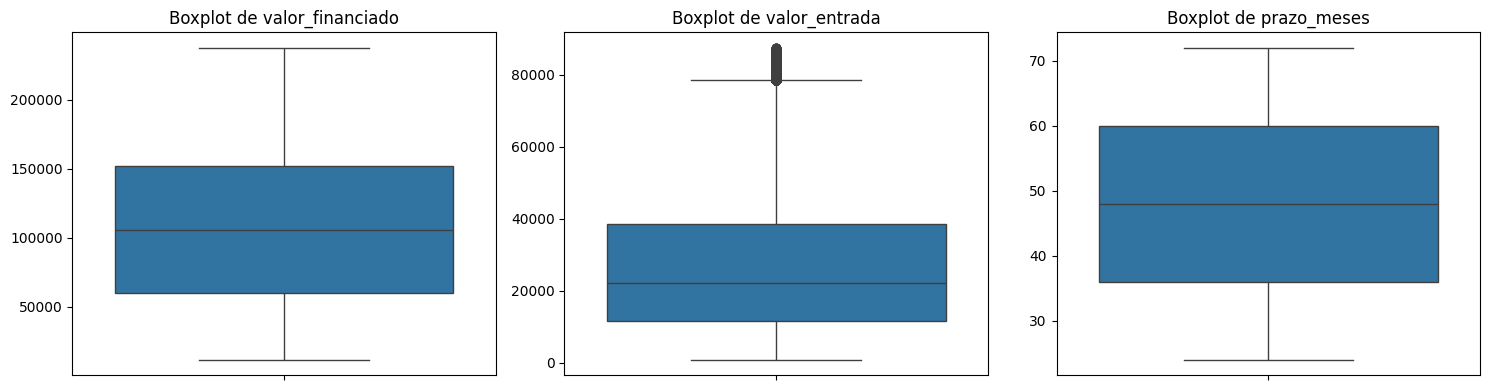

In [ ]:
# busca de outliers com boxplot para os campos numéricos
prop_num_cols = ['valor_financiado', 'valor_entrada', 'prazo_meses']
plot_numerical_boxplots(df_propostas, prop_num_cols)

In [ ]:
# Exemplo de uso da nova função para 'valor_entrada'
detectar_outliers_iqr(df_propostas, 'valor_entrada')

Número de outliers na coluna 'valor_entrada': 14352
Isso representa em porcentagem: 0.01%


## Base de eventos

In [ ]:
# análise preliminar de df_eventos: visão geral
df_eventos.head(10)

,id_proposta,evento_risco_chassi_90d,tipo_evento,dias_ate_evento
0,PROP_CHASSI_0000000001,0,SEM_EVENTO,NaN
1,PROP_CHASSI_0000000002,0,SEM_EVENTO,NaN
2,PROP_CHASSI_0000000003,0,SEM_EVENTO,NaN
3,PROP_CHASSI_0000000004,0,SEM_EVENTO,NaN
4,PROP_CHASSI_0000000005,0,SEM_EVENTO,NaN
5,PROP_CHASSI_0000000006,0,SEM_EVENTO,NaN
6,PROP_CHASSI_0000000007,0,SEM_EVENTO,NaN
7,PROP_CHASSI_0000000008,0,SEM_EVENTO,NaN
8,PROP_CHASSI_0000000009,0,SEM_EVENTO,NaN
9,PROP_CHASSI_0000000010,0,SEM_EVENTO,NaN


In [ ]:
# análise preliminar de df_eventos: colunas, tipos e avaliação de nulos
df_eventos.info()

# contagem de nulos
print("Campos Nulos por coluna")
print("-"*20)
df_eventos.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129213 entries, 0 to 2129212
Data columns (total 4 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   id_proposta              object 
 1   evento_risco_chassi_90d  int64  
 2   tipo_evento              object 
 3   dias_ate_evento          float64
dtypes: float64(1), int64(1), object(2)
memory usage: 65.0+ MB
Campos Nulos por coluna
--------------------


,0
id_proposta,0
evento_risco_chassi_90d,0
tipo_evento,0
dias_ate_evento,2098019


## Dicionário de Dados para `df_eventos`


| Campo                     | Possível descrição |
|:--------------------------|-------------------|
| `id_proposta`             | Código único de cada proposta de financiamento |
| `evento_risco_chassi_90d` | Indicador de evento de risco para o chassi nos próximos 90 dias (0 = sem evento, 1 = com evento) |
| `tipo_evento`             | Tipo de evento de risco (exe.: 'SEM_EVENTO', 'CALOTE_CARTAO', 'ROUBO_FURTO') |
| `dias_ate_evento`         | Número de dias até o evento de risco (NaN se `evento_risco_chassi_90d` for 0) |

## Conversão de Tipos para `df_eventos`


| Campo         | Tipo Bruto | Tipo Novo  |
|:--------------|:-----------|:-----------|
| `tipo_evento` | `object`   | `category` |

In [ ]:
# conversão de tipos df_eventos

df_eventos['tipo_evento'] = df_eventos['tipo_evento'].astype('category')

df_eventos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129213 entries, 0 to 2129212
Data columns (total 4 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   id_proposta              object  
 1   evento_risco_chassi_90d  int64   
 2   tipo_evento              category
 3   dias_ate_evento          float64 
dtypes: category(1), float64(1), int64(1), object(1)
memory usage: 50.8+ MB


In [ ]:
# análise preliminar de df_eventos: estatíticas de colunas numéricas
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df_eventos.describe())

,evento_risco_chassi_90d,dias_ate_evento
count,2129213.00,31194.00
mean,0.01,45.41
std,0.12,25.96
min,0.00,1.00
25%,0.00,23.00
50%,0.00,46.00
75%,0.00,68.00
max,1.00,90.00


In [ ]:
# análise preliminar de df_eventos: estatíticas de colunas não numéricas
df_eventos.describe(include='object')

,id_proposta
count,2129213
unique,2129213
top,PROP_CHASSI_0002129213
freq,1


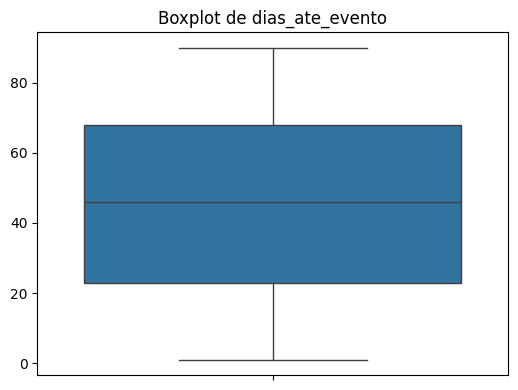

In [ ]:
# busca de outliers com boxplot para os campos numéricos
eventos_num_cols = ['dias_ate_evento']
plot_numerical_boxplots(df_eventos, eventos_num_cols)


### Base Chassis

In [ ]:
# análise preliminar de df_chassis: visão geral
df_chassis.head(10)

,chassi_id_sintetico,placa_id_sintetica,marca,ano_modelo,uf_registro,valor_fipe_referencia
0,CHASSI_SYN_000000001,PLACA_SYN_00000001,CHEVROLET,2019,PE,88100.75
1,CHASSI_SYN_000000002,PLACA_SYN_00000002,FORD,2009,CE,41263.09
2,CHASSI_SYN_000000003,PLACA_SYN_00000003,HYUNDAI,2009,PR,61890.28
3,CHASSI_SYN_000000004,PLACA_SYN_00000004,CHEVROLET,2015,RJ,77819.53
4,CHASSI_SYN_000000005,PLACA_SYN_00000005,HONDA,2020,CE,54864.68
5,CHASSI_SYN_000000006,PLACA_SYN_00000006,CHEVROLET,2024,SC,47140.72
6,CHASSI_SYN_000000007,PLACA_SYN_00000007,FIAT,2019,SP,112595.35
7,CHASSI_SYN_000000008,PLACA_SYN_00000008,FIAT,2025,MG,117532.89
8,CHASSI_SYN_000000009,PLACA_SYN_00000009,JEEP,2017,SC,269189.13
9,CHASSI_SYN_000000010,PLACA_SYN_00000010,CHEVROLET,2010,CE,92677.44


In [ ]:
# análise preliminar de df_chassis: colunas, tipos e avaliação de nulos
df_chassis.info()

# contagem de nulos
print("Campos Nulos por coluna")
print("-"*20)
df_chassis.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   chassi_id_sintetico    600000 non-null  object 
 1   placa_id_sintetica     600000 non-null  object 
 2   marca                  600000 non-null  object 
 3   ano_modelo             600000 non-null  int64  
 4   uf_registro            600000 non-null  object 
 5   valor_fipe_referencia  600000 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ MB
Campos Nulos por coluna
--------------------


,0
chassi_id_sintetico,0
placa_id_sintetica,0
marca,0
ano_modelo,0
uf_registro,0
valor_fipe_referencia,0


## Dicionário de Dados para `df_chassis`


| Campo                  | Possível descrição |
|:-----------------------|:-------------------|
| `chassi_id_sintetico`  | Código único do chassi do veículo |
| `placa_id_sintetica`   | Código sintético da placa do veículo |
| `marca`                | Marca do veículo |
| `ano_modelo`           | Ano do modelo do veículo |
| `uf_registro`          | Estado de registro do veículo |
| `valor_fipe_referencia`| Valor FIPE de referência do veículo |

## Conversão de Tipos para `df_chassis`

Para otimizar o uso de memória e facilitar análises futuras.

| Campo                  | Tipo Bruto | Tipo Novo  |
|:-----------------------|:-----------|:-----------|
| `marca`                | `object`   | `category` |
| `uf_registro`          | `object`   | `category` |

In [ ]:
# conversão de tipos

df_chassis['marca'] = df_chassis['marca'].astype('category')
df_chassis['uf_registro'] = df_chassis['uf_registro'].astype('category')

df_chassis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   chassi_id_sintetico    600000 non-null  object  
 1   placa_id_sintetica     600000 non-null  object  
 2   marca                  600000 non-null  category
 3   ano_modelo             600000 non-null  int64   
 4   uf_registro            600000 non-null  category
 5   valor_fipe_referencia  600000 non-null  float64 
dtypes: category(2), float64(1), int64(1), object(2)
memory usage: 19.5+ MB


In [ ]:
# análise preliminar de df_chassis: estatíticas de colunas numéricas
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df_chassis.describe())

,ano_modelo,valor_fipe_referencia
count,600000.00,600000.00
mean,2017.01,92824.89
std,5.48,53761.85
min,2008.00,18000.00
25%,2012.00,55216.21
50%,2017.00,80057.08
75%,2022.00,115996.19
max,2026.00,350000.00


In [ ]:
# análise preliminar de df_chassis: estatíticas de colunas não numéricas
df_chassis.describe(include='object')

,chassi_id_sintetico,placa_id_sintetica
count,600000,600000
unique,600000,600000
top,CHASSI_SYN_000599984,PLACA_SYN_00599984
freq,1,1


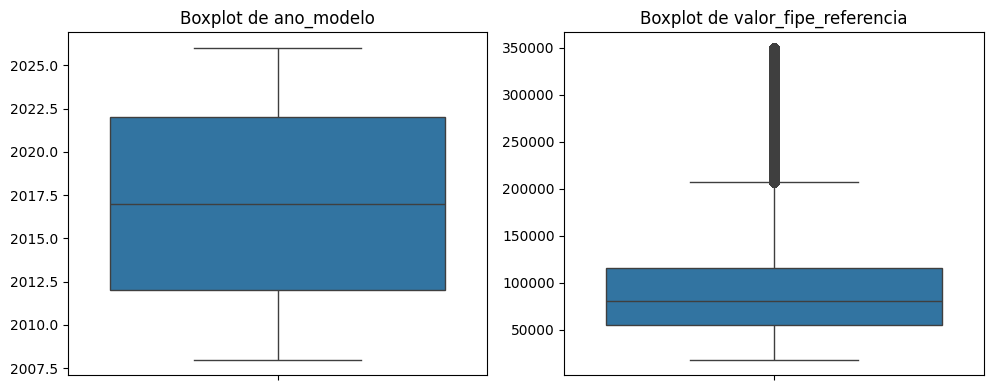

In [ ]:
# busca de outliers com boxplot para os campos numéricos
chassis_num_cols = ['ano_modelo', 'valor_fipe_referencia']
plot_numerical_boxplots(df_chassis, chassis_num_cols)

In [ ]:
# contagem de outliers no campo valor_fipe_referencia
detectar_outliers_iqr(df_chassis, 'valor_fipe_referencia')

Número de outliers na coluna 'valor_fipe_referencia': 25021
Isso representa em porcentagem: 0.04%


In [ ]:
# quantas compras foram a vista?

df = df_propostas.merge(df_eventos, on="id_proposta", how="inner")
df["data_proposta"] = pd.to_datetime(df["data_proposta"])
df.shape

df2 = df.merge(df_chassis, on="chassi_id_sintetico", how="left")
df2[["marca","ano_modelo","uf_registro","valor_fipe_referencia"]].isna().mean().to_frame("pct_nulo")


,pct_nulo
marca,0.0
ano_modelo,0.0
uf_registro,0.0
valor_fipe_referencia,0.0


In [ ]:
df2["valor_total"] = df2["valor_financiado"] + df2["valor_entrada"]
df2["ratio_entrada"] = (df2["valor_entrada"] / df2["valor_total"]).round(4)
df2["ratio_fipe"] = (df2["valor_total"] / df2["valor_fipe_referencia"]).round(4)
df2["entrada_fipe"] = (df2["valor_entrada"] / df2["valor_fipe_referencia"]).round(4)
df2.head()

,id_proposta,chassi_id_sintetico,if_id_sintetico,cpf_cnpj_proponente_sintetico,tipo_proponente,valor_financiado,valor_entrada,prazo_meses,canal,uf_proposta,...,dias_ate_evento,placa_id_sintetica,marca,ano_modelo,uf_registro,valor_fipe_referencia,valor_total,ratio_entrada,ratio_fipe,entrada_fipe
0,PROP_CHASSI_0000000001,CHASSI_SYN_000035285,IF_SYN_09,DOC_PROP_SYN_000376285,PF,125170.86,48209.12,36,DIGITAL,RJ,...,NaN,PLACA_SYN_00035285,CHEVROLET,2013,BA,51609.59,173379.98,0.2781,3.3595,0.9341
1,PROP_CHASSI_0000000002,CHASSI_SYN_000375721,IF_SYN_18,DOC_PROP_SYN_000235987,PF,34455.69,14855.02,24,DIGITAL,MG,...,NaN,PLACA_SYN_00375721,FORD,2019,CE,199948.26,49310.71,0.3013,0.2466,0.0743
2,PROP_CHASSI_0000000003,CHASSI_SYN_000416248,IF_SYN_15,DOC_PROP_SYN_000297726,PF,72615.57,16251.28,60,CONCESSIONARIA,SP,...,NaN,PLACA_SYN_00416248,HYUNDAI,2013,PR,114773.08,88866.85,0.1829,0.7743,0.1416
3,PROP_CHASSI_0000000004,CHASSI_SYN_000261667,IF_SYN_09,DOC_PROP_SYN_000593250,PF,116392.04,51887.97,60,LOJA_MULTIMARCA,PR,...,NaN,PLACA_SYN_00261667,HONDA,2012,CE,105924.11,168280.01,0.3083,1.5887,0.4899
4,PROP_CHASSI_0000000005,CHASSI_SYN_000089408,IF_SYN_11,DOC_PROP_SYN_000656252,PF,114506.18,55065.28,24,DIGITAL,SP,...,NaN,PLACA_SYN_00089408,JEEP,2013,PE,95611.75,169571.46,0.3247,1.7735,0.5759


In [ ]:
# organizar histórico de chassis primeiro pelo critério de data, depois pelo de hora e adicionar uma ordem para cada sequencia historia de chassi começando do 1


In [ ]:
df2 = df2.sort_values(by=['chassi_id_sintetico', 'data_proposta', 'hora_proposta'])
df2['ordem_historico_chassi'] = df2.groupby('chassi_id_sintetico').cumcount() + 1
display(df2.head(20))

,id_proposta,chassi_id_sintetico,if_id_sintetico,cpf_cnpj_proponente_sintetico,tipo_proponente,valor_financiado,valor_entrada,prazo_meses,canal,uf_proposta,...,placa_id_sintetica,marca,ano_modelo,uf_registro,valor_fipe_referencia,valor_total,ratio_entrada,ratio_fipe,entrada_fipe,ordem_historico_chassi
1629493,PROP_CHASSI_0001629494,CHASSI_SYN_000000001,IF_SYN_19,DOC_PROP_SYN_000161993,PJ,111694.29,20857.49,24,CONCESSIONARIA,MG,...,PLACA_SYN_00000001,CHEVROLET,2019,PE,88100.75,132551.78,0.1574,1.5045,0.2367,1
1922837,PROP_CHASSI_0001922838,CHASSI_SYN_000000002,IF_SYN_15,DOC_PROP_SYN_000026373,PF,40325.62,14324.16,24,DIGITAL,GO,...,PLACA_SYN_00000002,FORD,2009,CE,41263.09,54649.78,0.2621,1.3244,0.3471,1
2119570,PROP_CHASSI_0002119571,CHASSI_SYN_000000002,IF_SYN_02,DOC_PROP_SYN_000249555,PJ,168768.32,53555.71,60,CONCESSIONARIA,RJ,...,PLACA_SYN_00000002,FORD,2009,CE,41263.09,222324.03,0.2409,5.3880,1.2979,2
1843415,PROP_CHASSI_0001843416,CHASSI_SYN_000000002,IF_SYN_16,DOC_PROP_SYN_000388553,PJ,57018.44,9478.08,24,DIGITAL,MG,...,PLACA_SYN_00000002,FORD,2009,CE,41263.09,66496.52,0.1425,1.6115,0.2297,3
1474583,PROP_CHASSI_0001474584,CHASSI_SYN_000000003,IF_SYN_17,DOC_PROP_SYN_000067251,PF,116952.91,30867.09,24,LOJA_MULTIMARCA,PE,...,PLACA_SYN_00000003,HYUNDAI,2009,PR,61890.28,147820.00,0.2088,2.3884,0.4987,1
1936076,PROP_CHASSI_0001936077,CHASSI_SYN_000000003,IF_SYN_01,DOC_PROP_SYN_000614236,PF,139508.58,18762.26,24,DIGITAL,SP,...,PLACA_SYN_00000003,HYUNDAI,2009,PR,61890.28,158270.84,0.1185,2.5573,0.3032,2
1858798,PROP_CHASSI_0001858799,CHASSI_SYN_000000003,IF_SYN_17,DOC_PROP_SYN_000816466,PF,33330.02,4843.25,72,CONCESSIONARIA,RS,...,PLACA_SYN_00000003,HYUNDAI,2009,PR,61890.28,38173.27,0.1269,0.6168,0.0783,3
1543992,PROP_CHASSI_0001543993,CHASSI_SYN_000000003,IF_SYN_05,DOC_PROP_SYN_000382280,PF,92383.83,36011.35,24,CONCESSIONARIA,RS,...,PLACA_SYN_00000003,HYUNDAI,2009,PR,61890.28,128395.18,0.2805,2.0746,0.5819,4
198787,PROP_CHASSI_0000198788,CHASSI_SYN_000000004,IF_SYN_09,DOC_PROP_SYN_000526808,PF,159904.05,28899.42,36,CONCESSIONARIA,MG,...,PLACA_SYN_00000004,CHEVROLET,2015,RJ,77819.53,188803.47,0.1531,2.4262,0.3714,1
262251,PROP_CHASSI_0000262252,CHASSI_SYN_000000004,IF_SYN_15,DOC_PROP_SYN_000168279,PF,117977.04,51847.59,36,CONCESSIONARIA,MG,...,PLACA_SYN_00000004,CHEVROLET,2015,RJ,77819.53,169824.63,0.3053,2.1823,0.6663,2


In [ ]:
chassis_com_evento = df2[df2['evento_risco_chassi_90d'] == 1]['chassi_id_sintetico'].unique()
df_filtrado_por_evento = df2[df2['chassi_id_sintetico'].isin(chassis_com_evento)]
df_filtrado_por_evento[['chassi_id_sintetico', 'ratio_entrada', 'canal', 'uf_proposta', 'ratio_fipe','entrada_fipe','valor_total','prazo_meses', 'tipo_proponente', 'tipo_evento','ordem_historico_chassi', 'data_proposta']].head(20)

,chassi_id_sintetico,ratio_entrada,canal,uf_proposta,ratio_fipe,entrada_fipe,valor_total,prazo_meses,tipo_proponente,tipo_evento,ordem_historico_chassi,data_proposta
248748,CHASSI_SYN_000000014,0.2735,CONCESSIONARIA,BA,3.7997,1.0392,169969.58,72,PJ,SEM_EVENTO,1,2026-01-27
373956,CHASSI_SYN_000000014,0.3126,DIGITAL,PE,5.5266,1.7275,247216.05,60,PF,SEM_EVENTO,2,2026-01-29
974789,CHASSI_SYN_000000014,0.2060,CONCESSIONARIA,BA,4.4731,0.9216,200091.97,72,PJ,FRAUDE_CONFIRMADA,3,2026-02-11
1045132,CHASSI_SYN_000000014,0.1486,DIGITAL,BA,4.6986,0.6981,210178.09,72,PF,SEM_EVENTO,4,2026-02-25
1906055,CHASSI_SYN_000000014,0.1914,DIGITAL,PE,5.1513,0.9860,230431.98,48,PJ,SEM_EVENTO,5,2026-03-11
1216896,CHASSI_SYN_000000024,0.1838,LOJA_MULTIMARCA,PE,3.4657,0.6369,243185.26,36,PF,SEM_EVENTO,1,2026-02-14
855494,CHASSI_SYN_000000024,0.1993,CONCESSIONARIA,MG,1.4011,0.2793,98315.53,60,PF,SEM_EVENTO,2,2026-02-18
2038896,CHASSI_SYN_000000024,0.3337,CONCESSIONARIA,SP,3.4307,1.1447,240724.07,72,PF,NEVER_PAY,3,2026-03-12
439085,CHASSI_SYN_000000036,0.3484,DIGITAL,SP,4.4378,1.5461,211299.46,72,PF,SEM_EVENTO,1,2026-01-28
1298383,CHASSI_SYN_000000036,0.1950,LOJA_MULTIMARCA,RS,1.5648,0.3051,74505.37,48,PJ,BUSCA_APREENSAO_INFRUTIFERA,2,2026-02-20


In [ ]:
eventos_com_evento= df_filtrado_por_evento[df_filtrado_por_evento['tipo_evento'] != 'SEM_EVENTO']
print(f"O número de entradas sem 'SEM_EVENTO' é: {len(eventos_com_evento)}")

O número de entradas sem 'SEM_EVENTO' é: 31194


In [ ]:
ultima_ordem_por_chassi = eventos_com_evento.groupby('chassi_id_sintetico')['ordem_historico_chassi'].max().reset_index()

contagem_ultima_ordem = ultima_ordem_por_chassi['ordem_historico_chassi'].value_counts().reset_index()
contagem_ultima_ordem.columns = ['ordem_historico_chassi', 'contagem_chassis_ultima_ordem']

tab_if = tab_if.merge(contagem_ultima_ordem, on='ordem_historico_chassi', how='left')
tab_if['contagem_chassis_ultima_ordem'] = tab_if['contagem_chassis_ultima_ordem'].fillna(0).astype(int)

display(tab_if)

NameError: name 'tab_if' is not defined

In [ ]:
# 1. Ordenar o DataFrame de histórico (df_filtrado_por_evento) por chassi e data
df_filtrado_por_evento_sorted = df_filtrado_por_evento.sort_values(by=['chassi_id_sintetico', 'data_proposta']).copy()

# 2. Função para calcular cumulativamente os estados únicos para cada chassi
def cumulative_nunique_uf(group):
    unique_ufs = set()
    cumulative_counts = []
    for uf in group['uf_proposta']:
        unique_ufs.add(uf)
        cumulative_counts.append(len(unique_ufs))
    return pd.Series(cumulative_counts, index=group.index)

# Aplicar a função para criar a coluna de contagem cumulativa de estados
df_filtrado_por_evento_sorted['num_estados_ate_evento_cum'] = (
    df_filtrado_por_evento_sorted.groupby('chassi_id_sintetico', group_keys=False)
    .apply(cumulative_nunique_uf)
)

# 3. Mesclar a nova coluna com eventos_com_evento
eventos_com_evento = eventos_com_evento.merge(
    df_filtrado_por_evento_sorted[['chassi_id_sintetico', 'data_proposta', 'num_estados_ate_evento_cum']],
    on=['chassi_id_sintetico', 'data_proposta'],
    how='left'
)

# Renomear a coluna para o nome final
eventos_com_evento.rename(columns={'num_estados_ate_evento_cum': 'num_estados_ate_evento'}, inplace=True)

# Exibir as primeiras linhas com a nova coluna
display(eventos_com_evento[['chassi_id_sintetico', 'data_proposta', 'tipo_evento', 'uf_proposta', 'num_estados_ate_evento']].head())

# Exibir a distribuição do número de estados
print("\nDistribuição do número de estados únicos até a ocorrência do evento:")
display(eventos_com_evento['num_estados_ate_evento'].value_counts().sort_index())

/tmp/ipykernel_2817/3234140835.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cumulative_nunique_uf)


,chassi_id_sintetico,data_proposta,tipo_evento,uf_proposta,num_estados_ate_evento
0,CHASSI_SYN_000000014,2026-02-11,FRAUDE_CONFIRMADA,BA,2
1,CHASSI_SYN_000000024,2026-03-12,NEVER_PAY,SP,3
2,CHASSI_SYN_000000036,2026-02-20,BUSCA_APREENSAO_INFRUTIFERA,RS,2
3,CHASSI_SYN_000000043,2026-03-23,FRAUDE_CONFIRMADA,MG,3
4,CHASSI_SYN_000000049,2026-02-10,FRAUDE_CONFIRMADA,PE,3



Distribuição do número de estados únicos até a ocorrência do evento:


,count
num_estados_ate_evento,
1,9474
2,9305
3,7049
4,4006
5,1851
6,541
7,134
8,31
9,2


## 5) Agregados por chassi (nível de histórico completo)

Vamos criar as features solicitadas para cada chassi:

- `total_trocas_pf_pj`: número total de trocas PF↔PJ ao longo de todo o histórico do chassi.
- `teve_troca_pf_pj`: 1 se `total_trocas_pf_pj > 0`, senão 0.
- `primeiro_tipo`: 0 (PF) ou 1 (PJ) para o tipo do proponente na primeira proposta do chassi.
- `ultimo_tipo`: 0 (PF) ou 1 (PJ) para o tipo do proponente na última proposta do chassi.
- `padrao_mudanca`: codificação categórica transformada em numérica:
    - `0` = sempre PF
    - `1` = sempre PJ
    - `2` = PF→PJ (apenas uma troca)
    - `3` = PJ→PF (apenas uma troca)
    - `4` = múltiplas trocas (ou qualquer outro padrão)

In [ ]:
# Agrupar df2 por chassi_id_sintetico para calcular as features agregadas
df_chassi_features = df2.groupby('chassi_id_sintetico').agg(
    tipos_sequence=('tipo_proponente', lambda x: list(x)),
    primeiro_tipo_raw=('tipo_proponente', 'first'),
    ultimo_tipo_raw=('tipo_proponente', 'last')
).reset_index()

# Função para calcular total_trocas_pf_pj
def calculate_total_trocas(tipo_list):
    if len(tipo_list) <= 1:
        return 0
    changes = 0
    for i in range(1, len(tipo_list)):
        if tipo_list[i] != tipo_list[i-1]:
            changes += 1
    return changes

df_chassi_features['total_trocas_pf_pj'] = df_chassi_features['tipos_sequence'].apply(calculate_total_trocas)

# Criar teve_troca_pf_pj
df_chassi_features['teve_troca_pf_pj'] = (df_chassi_features['total_trocas_pf_pj'] > 0).astype(int)

# Codificar primeiro_tipo e ultimo_tipo
df_chassi_features['primeiro_tipo'] = df_chassi_features['primeiro_tipo_raw'].map({'PF': 0, 'PJ': 1})
df_chassi_features['ultimo_tipo'] = df_chassi_features['ultimo_tipo_raw'].map({'PF': 0, 'PJ': 1})

# Função para atribuir o padrão de mudança
def assign_padrao_mudanca(row):
    total_trocas = row['total_trocas_pf_pj']
    primeiro_tipo_raw = row['primeiro_tipo_raw']
    ultimo_tipo_raw = row['ultimo_tipo_raw']

    if total_trocas == 0:
        return 0 if primeiro_tipo_raw == 'PF' else 1 # 0: sempre PF, 1: sempre PJ
    elif total_trocas == 1:
        if primeiro_tipo_raw == 'PF' and ultimo_tipo_raw == 'PJ':
            return 2 # PF -> PJ
        elif primeiro_tipo_raw == 'PJ' and ultimo_tipo_raw == 'PF':
            return 3 # PJ -> PF
    return 4 # Múltiplas trocas ou outro padrão

df_chassi_features['padrao_mudanca'] = df_chassi_features.apply(assign_padrao_mudanca, axis=1)

# Remover colunas intermediárias
df_chassi_features.drop(columns=['tipos_sequence', 'primeiro_tipo_raw', 'ultimo_tipo_raw'], inplace=True)

display(df_chassi_features.head())

,chassi_id_sintetico,total_trocas_pf_pj,teve_troca_pf_pj,primeiro_tipo,ultimo_tipo,padrao_mudanca
0,CHASSI_SYN_000000001,0,0,1,1,1
1,CHASSI_SYN_000000002,1,1,0,1,2
2,CHASSI_SYN_000000003,0,0,0,0,0
3,CHASSI_SYN_000000004,1,1,0,1,2
4,CHASSI_SYN_000000005,1,1,1,0,3


In [ ]:
df2_com_features = df2.copy()
df2_com_features = df2_com_features.merge(df_chassi_features, on='chassi_id_sintetico', how='left')

# 1. Garantir que o DataFrame esteja ordenado por chassi e data para cálculos de diferença de tempo
df2_com_features = df2_com_features.sort_values(by=['chassi_id_sintetico', 'data_proposta']).copy()

# 2. Identificar chassis que tiveram algum evento (para o cálculo da média)
chassis_com_eventos_globais = df2_com_features[df2_com_features['evento_risco_chassi_90d'] == 1]['chassi_id_sintetico'].unique()

# 3. Calcular a média de tempo entre propostas 'SEM_EVENTO' para cada chassi com evento
# Filtrar apenas as propostas 'SEM_EVENTO' para esses chassis
df_sem_evento_chassis_com_evento = df2_com_features[
    (df2_com_features['chassi_id_sintetico'].isin(chassis_com_eventos_globais)) &
    (df2_com_features['tipo_evento'] == 'SEM_EVENTO')
].copy()

# Calcular a diferença de tempo entre propostas consecutivas 'SEM_EVENTO' para cada chassi
df_sem_evento_chassis_com_evento['diff_temp_sem_evento'] = df_sem_evento_chassis_com_evento.groupby('chassi_id_sintetico')['data_proposta'].diff()

# Calcular a média dessas diferenças (em segundos) por chassi
avg_tempo_sem_evento_chassi = df_sem_evento_chassis_com_evento.groupby('chassi_id_sintetico')['diff_temp_sem_evento'].mean().dt.total_seconds()

# Mapear essa média de volta para o DataFrame principal
df2_com_features['avg_tempo_sem_evento_chassi_mapped'] = df2_com_features['chassi_id_sintetico'].map(avg_tempo_sem_evento_chassi)

# 4. Calcular o tempo entre a proposta atual e a proposta imediatamente anterior (em segundos)
df2_com_features['tempo_ate_evento_a_partir_ultimo_financiamento'] = df2_com_features.groupby('chassi_id_sintetico')['data_proposta'].diff().dt.total_seconds()

# 5. Criar a feature ratio_tempo_com_evento
# Inicializar com NaN
df2_com_features['ratio_tempo_com_evento'] = np.nan

# Calcular a razão apenas para as propostas que são eventos
# Certificar-se de evitar divisão por zero ou por NaN na média, caso não haja propostas SEM_EVENTO suficientes para o cálculo
cond_evento = df2_com_features['evento_risco_chassi_90d'] == 1
cond_divisor_valido = df2_com_features['avg_tempo_sem_evento_chassi_mapped'].notna() & (df2_com_features['avg_tempo_sem_evento_chassi_mapped'] != 0)

df2_com_features.loc[cond_evento & cond_divisor_valido, 'ratio_tempo_com_evento'] = \
    df2_com_features['tempo_ate_evento_a_partir_ultimo_financiamento'] / df2_com_features['avg_tempo_sem_evento_chassi_mapped']

# Exibir as primeiras linhas com a nova feature e algumas colunas relevantes para verificar
display(df2_com_features[
    ['chassi_id_sintetico', 'data_proposta', 'tipo_evento', 'evento_risco_chassi_90d',
     'tempo_ate_evento_a_partir_ultimo_financiamento', 'avg_tempo_sem_evento_chassi_mapped', 'ratio_tempo_com_evento']
].head(10))

,chassi_id_sintetico,data_proposta,tipo_evento,evento_risco_chassi_90d,tempo_ate_evento_a_partir_ultimo_financiamento,avg_tempo_sem_evento_chassi_mapped,ratio_tempo_com_evento
0,CHASSI_SYN_000000001,2026-03-28,SEM_EVENTO,0,NaN,NaN,NaN
1,CHASSI_SYN_000000002,2026-03-03,SEM_EVENTO,0,NaN,NaN,NaN
2,CHASSI_SYN_000000002,2026-03-07,SEM_EVENTO,0,345600.0,NaN,NaN
3,CHASSI_SYN_000000002,2026-03-24,SEM_EVENTO,0,1468800.0,NaN,NaN
4,CHASSI_SYN_000000003,2026-02-04,SEM_EVENTO,0,NaN,NaN,NaN
5,CHASSI_SYN_000000003,2026-03-02,SEM_EVENTO,0,2246400.0,NaN,NaN
6,CHASSI_SYN_000000003,2026-03-03,SEM_EVENTO,0,86400.0,NaN,NaN
7,CHASSI_SYN_000000003,2026-03-29,SEM_EVENTO,0,2246400.0,NaN,NaN
8,CHASSI_SYN_000000004,2026-01-04,SEM_EVENTO,0,NaN,NaN,NaN
9,CHASSI_SYN_000000004,2026-01-21,SEM_EVENTO,0,1468800.0,NaN,NaN


### Nova Feature: Tempo médio entre financiamentos por ano de fabricação

In [ ]:
import numpy as np

# 1. Calcular a diferença de tempo entre propostas consecutivas para CADA chassi
#    (incluindo todas as propostas, independentemente do tipo de evento)
df2_com_features['diff_tempo_proposta_chassi'] = df2_com_features.groupby('chassi_id_sintetico')['data_proposta'].diff()

# 2. Calcular o tempo médio entre propostas por ANO DE MODELO
#    Convertendo a diferença para segundos para calcular a média numérica
avg_tempo_propostas_por_ano = df2_com_features.groupby('ano_modelo')['diff_tempo_proposta_chassi'].mean().dt.total_seconds()

# 3. Mapear essa média de volta para o DataFrame principal como uma nova feature
df2_com_features['avg_tempo_entre_propostas_ano_modelo'] = df2_com_features['ano_modelo'].map(avg_tempo_propostas_por_ano)

# Exibir as primeiras linhas com a nova feature e colunas relevantes para verificar
display(df2_com_features[
    ['chassi_id_sintetico', 'ano_modelo', 'data_proposta', 'diff_tempo_proposta_chassi', 'avg_tempo_entre_propostas_ano_modelo']
].sort_values(by=['chassi_id_sintetico', 'data_proposta']).head(20))

print(f"\nValores nulos na nova feature 'avg_tempo_entre_propostas_ano_modelo': {df2_com_features['avg_tempo_entre_propostas_ano_modelo'].isnull().sum()}")

,chassi_id_sintetico,ano_modelo,data_proposta,diff_tempo_proposta_chassi,avg_tempo_entre_propostas_ano_modelo
0,CHASSI_SYN_000000001,2019,2026-03-28,NaT,1.415877e+06
1,CHASSI_SYN_000000002,2009,2026-03-03,NaT,1.411547e+06
2,CHASSI_SYN_000000002,2009,2026-03-07,4 days,1.411547e+06
3,CHASSI_SYN_000000002,2009,2026-03-24,17 days,1.411547e+06
4,CHASSI_SYN_000000003,2009,2026-02-04,NaT,1.411547e+06
5,CHASSI_SYN_000000003,2009,2026-03-02,26 days,1.411547e+06
6,CHASSI_SYN_000000003,2009,2026-03-03,1 days,1.411547e+06
7,CHASSI_SYN_000000003,2009,2026-03-29,26 days,1.411547e+06
8,CHASSI_SYN_000000004,2015,2026-01-04,NaT,1.411437e+06
9,CHASSI_SYN_000000004,2015,2026-01-21,17 days,1.411437e+06



Valores nulos na nova feature 'avg_tempo_entre_propostas_ano_modelo': 0


In [ ]:
# Criar a feature de interação para o padrão de mudança 'PJ->PF'
# A feature avg_tempo_sem_evento_chassi_mapped já é um valor por chassi
# A feature padrao_mudanca também é um valor por chassi

df2_com_features['avg_tempo_pj_pf_interacao'] = np.where(
    df2_com_features['padrao_mudanca'] == 3, # 3 representa 'PJ->PF'
    df2_com_features['avg_tempo_sem_evento_chassi_mapped'],
    0 # Atribuir 0 para chassis que não se encaixam neste padrão
)

# Exibir algumas linhas relevantes para verificar a nova feature
display(df2_com_features[
    ['chassi_id_sintetico', 'padrao_mudanca', 'avg_tempo_sem_evento_chassi_mapped', 'avg_tempo_pj_pf_interacao']
].drop_duplicates(subset=['chassi_id_sintetico']).head(10))

print("\nContagem de valores não-zero na nova feature:")
print(f"{len(df2_com_features[df2_com_features['avg_tempo_pj_pf_interacao'] > 0].drop_duplicates(subset=['chassi_id_sintetico']))} chassis possuem a feature 'avg_tempo_pj_pf_interacao' com valor > 0 (padrão PJ->PF).")

,chassi_id_sintetico,padrao_mudanca,avg_tempo_sem_evento_chassi_mapped,avg_tempo_pj_pf_interacao
0,CHASSI_SYN_000000001,1,NaN,0.0
1,CHASSI_SYN_000000002,2,NaN,0.0
4,CHASSI_SYN_000000003,0,NaN,0.0
8,CHASSI_SYN_000000004,2,NaN,0.0
12,CHASSI_SYN_000000005,3,NaN,NaN
15,CHASSI_SYN_000000006,2,NaN,0.0
18,CHASSI_SYN_000000008,4,NaN,0.0
23,CHASSI_SYN_000000009,3,NaN,NaN
26,CHASSI_SYN_000000010,0,NaN,0.0
29,CHASSI_SYN_000000011,0,NaN,0.0



Contagem de valores não-zero na nova feature:
3203 chassis possuem a feature 'avg_tempo_pj_pf_interacao' com valor > 0 (padrão PJ->PF).


In [ ]:
# 2. Criar a nova feature de interação: avg_tempo_sem_evento_chassi_mapped * ratio_fipe
df2_com_features['interacao_avg_tempo_ratio_fipe'] = \
    df2_com_features['avg_tempo_sem_evento_chassi_mapped'] * df2_com_features['ratio_fipe']

# Exibir as primeiras linhas com a nova feature e colunas relevantes
display(df2_com_features[
    ['chassi_id_sintetico', 'avg_tempo_sem_evento_chassi_mapped', 'ratio_fipe', 'interacao_avg_tempo_ratio_fipe']
].drop_duplicates(subset=['chassi_id_sintetico']).head(10))

print("\nValores nulos na nova feature 'interacao_avg_tempo_ratio_fipe':")
display(df2_com_features['interacao_avg_tempo_ratio_fipe'].isnull().sum())

,chassi_id_sintetico,avg_tempo_sem_evento_chassi_mapped,ratio_fipe,interacao_avg_tempo_ratio_fipe
0,CHASSI_SYN_000000001,NaN,1.5045,NaN
1,CHASSI_SYN_000000002,NaN,1.3244,NaN
4,CHASSI_SYN_000000003,NaN,2.3884,NaN
8,CHASSI_SYN_000000004,NaN,2.4262,NaN
12,CHASSI_SYN_000000005,NaN,2.1373,NaN
15,CHASSI_SYN_000000006,NaN,1.4296,NaN
18,CHASSI_SYN_000000008,NaN,1.5985,NaN
23,CHASSI_SYN_000000009,NaN,0.1378,NaN
26,CHASSI_SYN_000000010,NaN,0.7073,NaN
29,CHASSI_SYN_000000011,NaN,7.4875,NaN



Valores nulos na nova feature 'interacao_avg_tempo_ratio_fipe':


np.int64(1998967)

In [ ]:
# Criar a feature de interação: avg_tempo_pj_pf_interacao * ratio_entrada
df2_com_features['interacao_pj_pf_ratio_entrada'] = \
    df2_com_features['avg_tempo_pj_pf_interacao'] * df2_com_features['ratio_entrada']

# Exibir as primeiras linhas com a nova feature
display(df2_com_features[
    ['chassi_id_sintetico', 'avg_tempo_pj_pf_interacao', 'ratio_entrada', 'interacao_pj_pf_ratio_entrada']
].drop_duplicates(subset=['chassi_id_sintetico']).head(10))

print("\nValores nulos na feature 'interacao_pj_pf_ratio_entrada':")
display(df2_com_features['interacao_pj_pf_ratio_entrada'].isnull().sum())

,chassi_id_sintetico,avg_tempo_pj_pf_interacao,ratio_entrada,interacao_pj_pf_ratio_entrada
0,CHASSI_SYN_000000001,0.0,0.1574,0.00
1,CHASSI_SYN_000000002,0.0,0.2621,0.00
4,CHASSI_SYN_000000003,0.0,0.2088,0.00
8,CHASSI_SYN_000000004,0.0,0.1531,0.00
12,CHASSI_SYN_000000005,907200.0,0.0906,82192.32
15,CHASSI_SYN_000000006,0.0,0.2301,0.00
18,CHASSI_SYN_000000008,0.0,0.1063,0.00
23,CHASSI_SYN_000000009,864000.0,0.3404,294105.60
26,CHASSI_SYN_000000010,0.0,0.0988,0.00
29,CHASSI_SYN_000000011,0.0,0.1858,0.00



Valores nulos na feature 'interacao_pj_pf_ratio_entrada':


np.int64(0)

In [ ]:
# Criar a feature de interação: avg_tempo_pj_pf_interacao * ratio_fipe
df2_com_features['interacao_pj_pf_ratio_fipe'] = \
    df2_com_features['avg_tempo_pj_pf_interacao'] * df2_com_features['ratio_fipe']

# Exibir as primeiras linhas com a nova feature
display(df2_com_features[
    ['chassi_id_sintetico', 'avg_tempo_pj_pf_interacao', 'ratio_fipe', 'interacao_pj_pf_ratio_fipe']
].drop_duplicates(subset=['chassi_id_sintetico']).head(10))

print("\nValores nulos na feature 'interacao_pj_pf_ratio_fipe':")
display(df2_com_features['interacao_pj_pf_ratio_fipe'].isnull().sum())

,chassi_id_sintetico,avg_tempo_pj_pf_interacao,ratio_fipe,interacao_pj_pf_ratio_fipe
0,CHASSI_SYN_000000001,0.0,1.5045,0.00
1,CHASSI_SYN_000000002,0.0,1.3244,0.00
4,CHASSI_SYN_000000003,0.0,2.3884,0.00
8,CHASSI_SYN_000000004,0.0,2.4262,0.00
12,CHASSI_SYN_000000005,907200.0,2.1373,1938958.56
15,CHASSI_SYN_000000006,0.0,1.4296,0.00
18,CHASSI_SYN_000000008,0.0,1.5985,0.00
23,CHASSI_SYN_000000009,864000.0,0.1378,119059.20
26,CHASSI_SYN_000000010,0.0,0.7073,0.00
29,CHASSI_SYN_000000011,0.0,7.4875,0.00



Valores nulos na feature 'interacao_pj_pf_ratio_fipe':


np.int64(0)

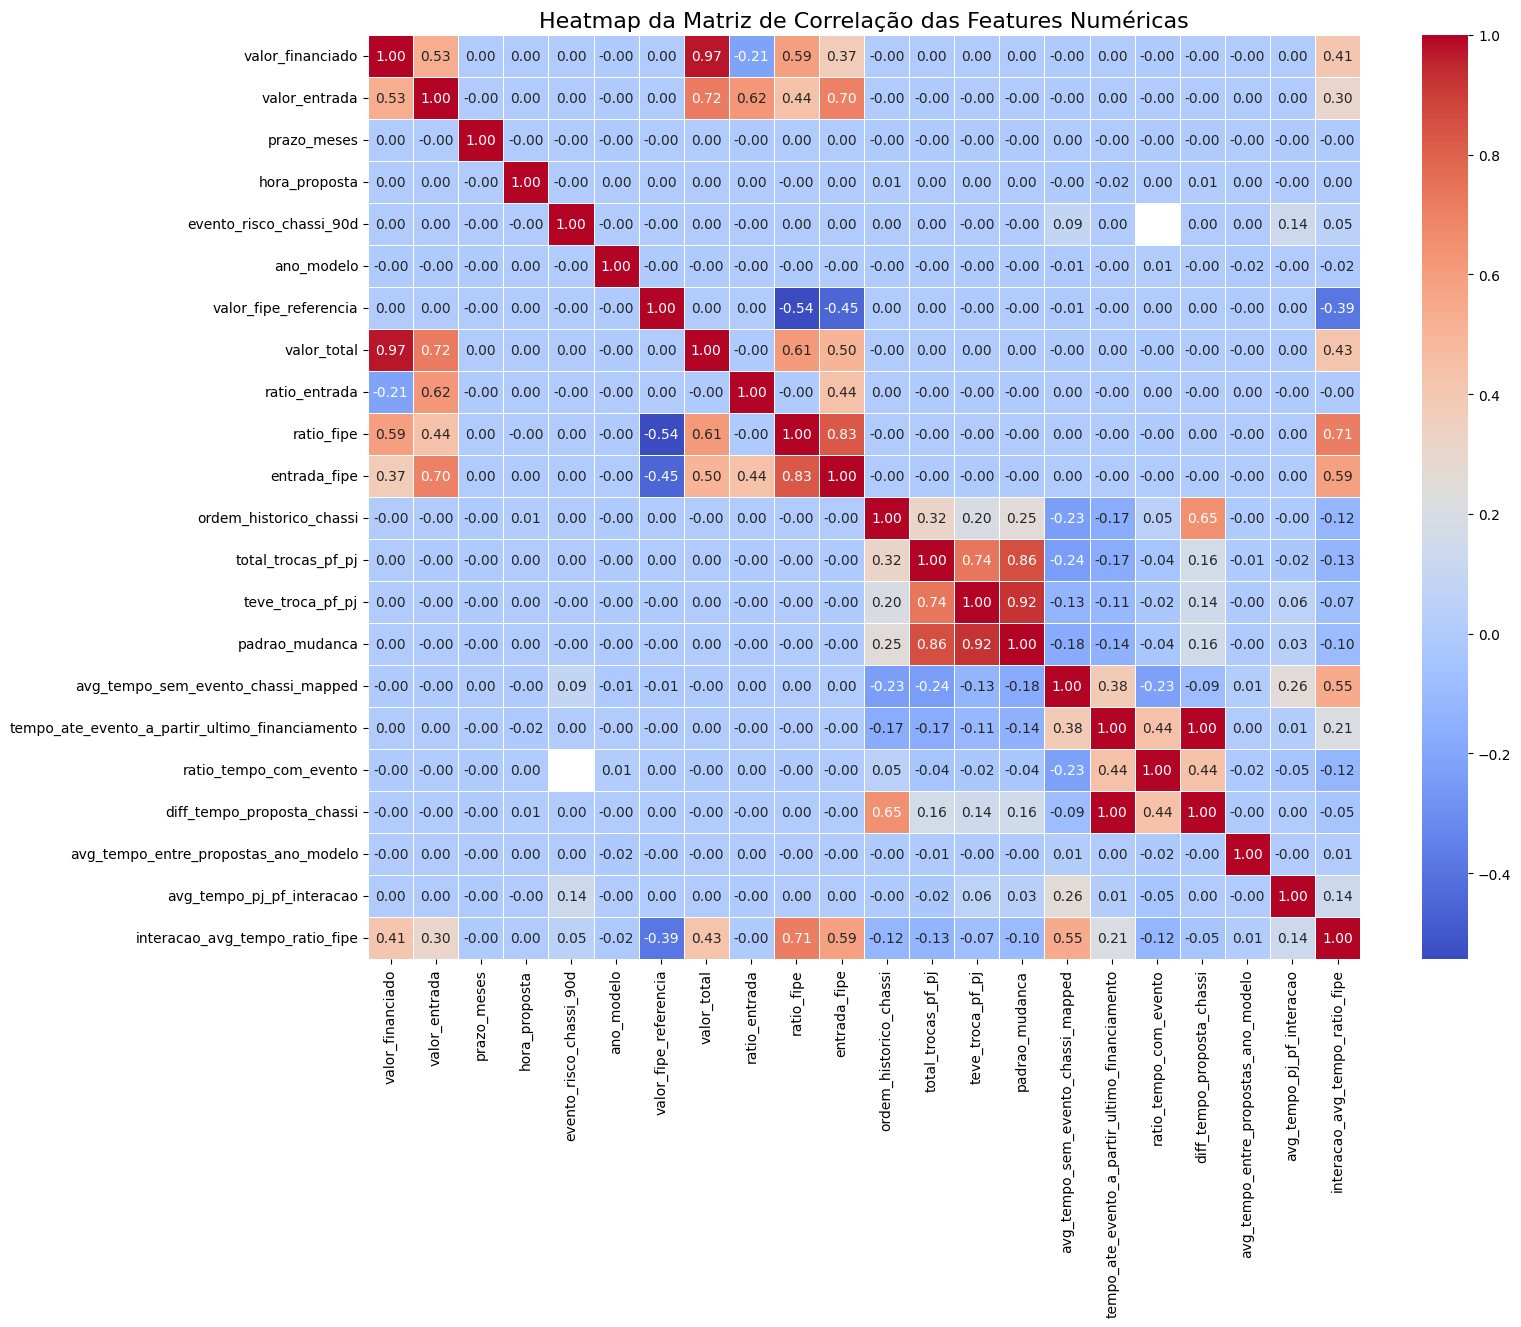

In [ ]:
# Selecionar apenas as colunas numéricas para o heatmap
# Excluir 'dias_ate_evento' pois tem muitos NaN e distorceria a correlação
# Excluir colunas de ID e data/hora para o heatmap de correlação
numeric_cols = df2_com_features.select_dtypes(include=np.number).columns.tolist()

# Remover colunas que não são relevantes para correlação ou que já são a target ou tem muitos NaNs
exclude_cols = ['dias_ate_evento'] # Esta coluna tem NaN apenas onde não há evento, o que atrapalha a correlação direta

numeric_cols_filtered = [col for col in numeric_cols if col not in exclude_cols]

df_numeric = df2_com_features[numeric_cols_filtered]

# Calcular a matriz de correlação
correlation_matrix = df_numeric.corr()

# Configurar a figura para o heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap da Matriz de Correlação das Features Numéricas', fontsize=16)
plt.show()



*   interacao_avg_tempo_ratio_fipe

      **Variáveis usadas:** avg_tempo_sem_evento_chassi_mapped (tempo médio entre propostas sem eventos de risco para um chassi) e ratio_fipe (razão entre o valor total financiado e o valor FIPE de referência do veículo).
     
     Essa feature busca entender se existe uma relação especial entre a frequência com que um chassi é financiado (representada pelo tempo médio entre propostas) e o quão o valor financiado se compara ao valor de mercado do veículo (ratio_fipe). Por exemplo, chassis que demoram mais para serem financiados e têm um 'ratio_fipe' muito alto (indicando um financiamento muito acima da FIPE) podem ter um perfil de risco diferente de chassis com as mesmas características, mas com 'ratio_fipe' mais próximo de 1.

* avg_tempo_pj_pf_interacao

    **Variáveis usadas:** padrao_mudanca (especificamente quando o padrão é de 'PJ para PF', ou seja, Pessoa Jurídica para Pessoa Física) e avg_tempo_sem_evento_chassi_mapped.
    
    Essa feature isola um comportamento específico: o chassi que muda de ser financiado por uma Pessoa Jurídica para uma Pessoa Física. O objetivo é analisar se essa transição, combinada com a frequência de financiamentos (tempo médio entre propostas sem evento), tem alguma implicação no risco. Se o chassi não teve essa mudança de PJ para PF, o valor dessa feature é zero, focando a análise apenas nos casos relevantes.

*  interacao_pj_pf_ratio_entrada

   **Variáveis usadas:** avg_tempo_pj_pf_interacao (a feature explicada acima) e ratio_entrada (a proporção do valor de entrada em relação ao valor total financiado).
  
    Esta é uma interação de 'segundo nível'. Ela pega a informação de 'chassi que mudou de PJ para PF com um certo tempo médio entre financiamentos' e a combina com a 'ratio_entrada'. A ideia é descobrir se, para esses chassis que passaram pela transição PJ para PF, o valor da entrada (maior ou menor) aumenta ou diminui o risco, considerando a frequência dos financiamentos. É uma forma de refinar ainda mais a identificação de padrões de risco complexos.
      
      



 avg_tempo_sem_evento_chassi_mapped:

  O que ela representa: Esta feature tenta capturar o "ritmo" ou a "frequência normal" de atividades (propostas de financiamento) de um chassi antes que um evento de risco aconteça. É o tempo médio, em segundos, entre propostas que não tiveram nenhum evento de risco para um dado chassi.
  

**Como é calculada:**

Primeiro, o sistema identifica quais chassis tiveram algum

evento de risco em seu histórico (mesmo que em propostas anteriores ou posteriores ao evento em questão).

Para apenas esses chassis, são consideradas somente as propostas que foram classificadas como 'SEM_EVENTO' (sem evento de risco).

Calcula-se a diferença de tempo entre cada uma dessas propostas consecutivas 'SEM_EVENTO' para o mesmo chassi.

A média dessas diferenças de tempo é então calculada para cada chassi, resultando no avg_tempo_sem_evento_chassi_mapped.
